<a href="https://colab.research.google.com/github/Ajendra11/Concepts-and-Technologies-of-AI/blob/main/2501936_AjendraRai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [457]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [458]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [459]:
# Load the provided HDI dataset
hdi_df = pd.read_csv("/content/drive/MyDrive/CAI/Human_Development_Index_Dataset.csv",encoding='latin1')


# **Problem 1 Basic Data Exploration & Trend Visualization**

## **3.1 Problem 1A: Single-Year HDI Exploration (Latest Year:2022)**

### **Task 1: Extract Latest Year**

In [460]:
# Identifying unique years in the dataset
print(hdi_df['year'].unique())

# Filtering the dataset to include only observations from the year 2022
# Saving the filtered dataframe as hdi 2022 df
hdi_2022_df = hdi_df[hdi_df['year'] == 2022].copy()

[1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022]


### **Task 2: Data Exploration**

In [461]:
#First 10 rows of 2022 dataset(hdi_2022_df)
display(hdi_2022_df.head(10))

,Unnamed: 0,iso3,country,year,hdi,life_expectancy,pop_millions,hdi_f,hdi_m,life_expec_f,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
32,33,AFG,Afghanistan,2022,0.462,62.879,41.128771,0.332443,0.534145,66.213,...,0.622,0.665,7.042050,24.077040,27.215190,72.784810,23.33,77.09,0.306318,1.1809
65,66,ALB,Albania,2022,0.789,76.833,2.842321,0.780277,0.798432,79.472,...,0.977,0.116,82.249185,86.476634,35.714286,64.285714,56.08,69.91,1.717758,11.7367
98,99,DZA,Algeria,2022,0.745,77.129,44.903225,0.681844,0.773800,78.457,...,0.881,0.460,42.910456,46.815170,7.005254,92.994746,17.57,65.53,4.079540,8.7199
131,132,AND,Andorra,2022,0.884,83.552,0.079824,NaN,NaN,85.838,...,NaN,NaN,81.718277,84.599998,46.428571,53.571429,NaN,NaN,4.593593,NaN
164,165,AGO,Angola,2022,0.591,61.929,35.588987,0.560890,0.619680,64.541,...,0.905,0.520,21.339865,37.411946,33.636364,66.363636,74.73,78.16,0.507359,3.6568
197,198,ATG,Antigua and Barbuda,2022,0.826,79.236,0.093763,NaN,NaN,81.645,...,NaN,NaN,NaN,NaN,31.428571,68.571429,NaN,NaN,6.401056,NaN
230,231,ARG,Argentina,2022,0.849,76.064,45.510318,0.841405,0.845473,79.277,...,0.995,0.292,73.591541,71.648085,44.376900,55.623100,52.08,71.74,4.190779,14.4512
263,264,ARM,Armenia,2022,0.786,73.372,2.780469,0.795110,0.774942,78.447,...,1.026,0.198,96.001381,97.050957,35.514019,64.485981,62.80,71.84,2.531088,7.3553
296,297,AUS,Australia,2022,0.946,83.579,26.177414,0.934602,0.955941,85.453,...,0.978,0.063,94.580063,94.430069,44.493392,55.506608,62.31,71.13,14.914763,26.9245
329,330,AUT,Austria,2022,0.926,82.412,8.939617,0.911592,0.937756,84.600,...,0.972,0.048,100.000000,100.000000,40.983607,59.016393,56.55,66.69,7.399461,27.9621


In [462]:
#Number of rows and columns
print("\nShape of hdi_2022_df (rows, columns):")
print(hdi_2022_df.shape)


Shape of hdi_2022_df (rows, columns):
(206, 30)


In [463]:
#column names and their data types
print("\nColumn names and their data types:")
print(hdi_2022_df.dtypes)


Column names and their data types:
Unnamed: 0                     int64
iso3                          object
country                       object
year                           int64
hdi                          float64
life_expectancy              float64
pop_millions                 float64
hdi_f                        float64
hdi_m                        float64
life_expec_f                 float64
life_expec_m                 float64
expec_yr_school              float64
expec_yr_school_f            float64
expec_yr_school_m            float64
mean_yr_school               float64
mean_yr_school_f             float64
mean_yr_school_m             float64
gross_inc_percap             float64
gross_inc_percap_f           float64
gross_inc_percap_m           float64
gender_development           float64
gender_inequality            float64
secondary_education_f_%      float64
secondary_education_m_%      float64
seats_in_parliament_f_%      float64
seats_in_parliament_m_%      float64
la

### **Task 3: Missing Values & Data Cleaning**

In [464]:
#Checking for missing values in each column
missing_counts = hdi_2022_df.isna().sum()
print("Missing values per column:\n", missing_counts)


Missing values per column:
 Unnamed: 0                    0
iso3                          0
country                       0
year                          0
hdi                           2
life_expectancy               0
pop_millions                  0
hdi_f                        13
hdi_m                        13
life_expec_f                  0
life_expec_m                  0
expec_yr_school               1
expec_yr_school_f             1
expec_yr_school_m             1
mean_yr_school                2
mean_yr_school_f              2
mean_yr_school_m              2
gross_inc_percap              2
gross_inc_percap_f           13
gross_inc_percap_m           13
gender_development           13
gender_inequality            29
secondary_education_f_%      17
secondary_education_m_%      17
seats_in_parliament_f_%       2
seats_in_parliament_m_%       2
labour_participation_f_%     12
labour_participation_m_%     12
co2_emission_tons             2
mat_footprint_percap_tons    41
dtype: int64

In [465]:
#numeric columns stored as text
print("Text columns:", list(hdi_2022_df.select_dtypes('object').columns))

Text columns: ['iso3', 'country']


In [466]:
#inconsistent or misspelled country names
print("Countries:", hdi_2022_df['Country'].nunique() if 'Country' in hdi_2022_df else "N/A")

Countries: N/A


In [467]:
#duplicate rows
print("Duplicates:", hdi_2022_df.duplicated().sum())


Duplicates: 0


In [468]:
# Inspect special characters representing missing data
missing_symbols = ['–', '-', '—']

hdi_2022_df.isin(missing_symbols).sum()


,0
Unnamed: 0,0
iso3,0
country,0
year,0
hdi,0
life_expectancy,0
pop_millions,0
hdi_f,0
hdi_m,0
life_expec_f,0


Applying necessary cleaning steps


In [469]:
#Converting numeric columns stored as text to numeric
numeric_cols = ['hdi', 'life_expectancy', 'gross_inc_percap']
for col in numeric_cols:
    hdi_2022_df[col] = pd.to_numeric(hdi_2022_df[col], errors='coerce')


In [470]:
# Drop duplicates
hdi_2022_df = hdi_2022_df.drop_duplicates()


In [471]:
#Replacing special characters representing missing data with NaN
hdi_2022_df = hdi_2022_df.replace(['–', '-', '—'], pd.NA)

In [472]:
#Handling missing values
#Droping rows with missing HDI (main variable)
rows_before = hdi_2022_df.shape[0]
hdi_2022_df = hdi_2022_df.dropna(subset=['hdi'])
rows_dropped = rows_before - hdi_2022_df.shape[0]
print("Rows dropped due to missing HDI:", rows_dropped)

Rows dropped due to missing HDI: 2


Data cleaning justification (2022):
- Special symbols such as `–`, `-`, and `—` were treated as missing values to avoid incorrect numeric conversion.
- Rows with missing **HDI** were removed (not imputed) because HDI is the primary outcome variable, and imputing it could bias rankings and category classification.
- Duplicate rows were removed to avoid double-counting countries.

### **Task 4: Basic Statistics**

In [473]:
# Computing the mean, median, and standard deviation of HDI for the year 2022.
print(f"Mean HDI (2022): {hdi_2022_df['hdi'].mean():.3f}")
print(f"Median HDI (2022): {hdi_2022_df['hdi'].median():.3f}")
print(f"Standard Deviation of HDI (2022): {hdi_2022_df['hdi'].std():.3f}")

Mean HDI (2022): 0.723
Median HDI (2022): 0.740
Standard Deviation of HDI (2022): 0.153


In [474]:
#Identify the country with the highest HDI in 2022.
highest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmax()]
lowest_hdi_country = hdi_2022_df.loc[hdi_2022_df['hdi'].idxmin()]

print("\nCountry with Highest HDI (2022):")
print(highest_hdi_country[['country', 'hdi']].to_string(index=False))

print("\nCountry with Lowest HDI (2022):")
print(lowest_hdi_country[['country', 'hdi']].to_string(index=False))


Country with Highest HDI (2022):
Switzerland
      0.967

Country with Lowest HDI (2022):
Somalia
   0.38


### **Task 5: Filtering and Sorting**

In [475]:
#Filtering countries with HDI {"hdi"} greater than 0.800.
high_hdi = hdi_2022_df[hdi_2022_df['hdi'] > 0.800]

#Sorting this filtered dataset by Gross National Income (GNI) per Capita {"gross inc percap"} in descending order.
high_hdi_sorted = high_hdi.sort_values(by='gross_inc_percap', ascending=False)

#Display the top 10 countries.
display(high_hdi_sorted[['country', 'hdi', 'gross_inc_percap']].head(10))

,country,hdi,gross_inc_percap
3332,Liechtenstein,0.942,146673.24150
4718,Qatar,0.875,95944.37754
5213,Singapore,0.949,88761.14559
2705,Ireland,0.950,87467.51391
3398,Luxembourg,0.927,78554.23640
6104,United Arab Emirates,0.937,74103.71494
5609,Switzerland,0.967,69432.78669
4322,Norway,0.966,69189.76165
6170,United States,0.927,65564.93798
2474,"Hong Kong, China (SAR)",0.956,62485.50516


### **Task 6: Adding HDI Category Column**

In [476]:
#Creating a new column HDI Category
def hdi_category(hdi):
    if hdi < 0.550:
        return 'Low'
    elif hdi < 0.700:
        return 'Medium'
    elif hdi < 0.800:
        return 'High'
    else:
        return 'Very High'

hdi_2022_df['HDI Category'] = hdi_2022_df['hdi'].apply(hdi_category)

# Verification
print(hdi_2022_df[['country', 'hdi', 'HDI Category']].head())

         country    hdi HDI Category
32   Afghanistan  0.462          Low
65       Albania  0.789         High
98       Algeria  0.745         High
131      Andorra  0.884    Very High
164       Angola  0.591       Medium


In [477]:
#ensuring the updated dataframe includes the new category column or not.
print(hdi_2022_df['HDI Category'].value_counts())

HDI Category
Very High    71
High         54
Medium       44
Low          35
Name: count, dtype: int64


In [478]:

file_path = '/content/drive/MyDrive/CAI/hdi_2022_cleaned.csv'

# Save the cleaned DataFrame as CSV
hdi_2022_df.to_csv(file_path, index=False)

print(f"hdi_2022_cleaned.csv saved successfully..")


hdi_2022_cleaned.csv saved successfully..


## **3.2 Problem 1B: HDI Visualization and Trend Analysis (2020 – 2022)**

### **Task 1 :Data Extraction and Saving**

In [479]:
# Filter the dataset for years 2020, 2021, and 2022
hdi_1b = hdi_df[hdi_df['year'].isin([2020, 2021, 2022])].copy()

file_path = '/content/drive/MyDrive/CAI/HDI_problem1B.csv'
# Save the filtered dataset for Problem 1B
hdi_1b.to_csv(file_path, index=False)

print("Filtered dataset saved as HDI_problem1B.csv and ready for Problem 1B tasks!")


Filtered dataset saved as HDI_problem1B.csv and ready for Problem 1B tasks!


**Task 2 :Data Cleaning**

In [480]:
#Checking for missing values
essential_cols = ['hdi', 'country', 'year']
for col in essential_cols:
    missing = hdi_1b[col].isnull().sum()
    if missing > 0:
        print(f"{col}: {missing} missing values")
    else:
        print(f"{col}: No missing values")

hdi: 8 missing values
country: No missing values
year: No missing values


In [481]:
#Inspecting inconsistent or misspelled country names
print("Unique country names in the dataset:")
print(hdi_1b['country'].unique(), "\n")

#Identifying duplicate rows
num_duplicates = hdi_1b.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}\n")

#Inspecting numeric columns for non-numeric symbols (like '–')
numeric_cols = ['hdi']  # add other numeric columns if needed
for col in numeric_cols:
    non_numeric = hdi_1b[~hdi_1b[col].apply(lambda x: pd.api.types.is_number(x))]
    if not non_numeric.empty:
        print(f"Non-numeric or special characters found in column '{col}':")
        display(non_numeric[[col]].drop_duplicates())
        print()

Unique country names in the dataset:
['Afghanistan' 'Albania' 'Algeria' 'Andorra' 'Angola'
 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus'
 'Belgium' 'Belize' 'Benin' 'Bhutan' 'Bolivia (Plurinational State of)'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei Darussalam'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde' 'Cambodia' 'Cameroon'
 'Canada' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo' 'Congo (Democratic Republic of the)' 'Costa Rica'
 "Côte d'Ivoire" 'Croatia' 'Cuba' 'Cyprus' 'Czechia' 'Denmark' 'Djibouti'
 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini (Kingdom of)'
 'Ethiopia' 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany'
 'Ghana' 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana'
 'Haiti' 'Honduras' 'Hong Kong, China (SAR)' 'Hungary' 'Iceland' 'India

In [482]:
#cleaning
#Droping rows with missing values in essential columns
hdi_1b = hdi_1b.dropna(subset=['hdi', 'country', 'year'])

#Replacing special characters representing missing data
hdi_1b = hdi_1b.replace(['–', '-', '—'], pd.NA)

#Converting numeric columns to proper type
for col in numeric_cols:
    hdi_1b[col] = pd.to_numeric(hdi_1b[col], errors='coerce')

#Droping rows that became NaN after conversion
hdi_1b = hdi_1b.dropna(subset=numeric_cols)

#Removing duplicate rows
hdi_1b = hdi_1b.drop_duplicates()

#Ensuring consistent naming conventions for countries and years
hdi_1b['country'] = hdi_1b['country'].str.strip().str.title()
hdi_1b['year'] = hdi_1b['year'].astype(int)


**Data Cleaning Justification (2020–2022)**

To ensure the integrity and reliability of the longitudinal analysis, the following cleaning steps were performed:

1. Handling Missing Values: Rows missing critical identifiers—Human Development Index (HDI), Country, or Year—were dropped. These fields are foundational for cross-country trend comparisons; imputing them would introduce significant bias.

2. Numeric Standardization: Data types were standardized across all features. Numeric-like columns were converted using pd.to_numeric(..., errors='coerce') to handle non-numeric symbols or placeholders. Any rows resulting in invalid data for core metrics were removed.

3. Deduplication: Duplicate entries were identified and removed to ensure that each country-year observation is unique, preventing the over-weighting of specific data points in the final analysis.

4. String Consistency: To facilitate accurate joins and grouping, country names were standardized by correcting capitalization and stripping leading/trailing whitespace.

5. Temporal Formatting: The Year column was explicitly cast to an integer type. This ensures proper chronological sorting and prevents errors during time-series visualizations.

### **Task 3 : Visualization**

### **A. Line Chart — HDI Trend (Country-Level):**

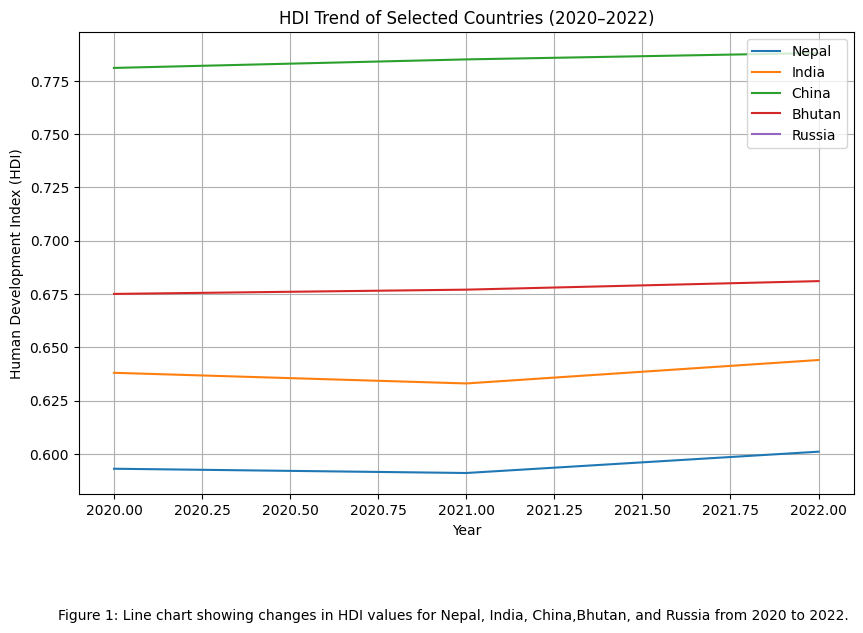

In [483]:
# Line Chart: HDI Trend (5 Countries)
countries = ['Nepal', 'India', 'China', 'Bhutan', 'Russia']
subset = hdi_1b[hdi_1b['country'].isin(countries)]

plt.figure(figsize=(10, 6))
for c in countries:
    data = subset[subset['country'] == c]
    plt.plot(data['year'], data['hdi'], label=c)
plt.xlabel('Year')
plt.ylabel('Human Development Index (HDI)')
plt.title('HDI Trend of Selected Countries (2020–2022)')
plt.grid(True)
plt.legend()
plt.figtext(
    0.5, -0.1,
    'Figure 1: Line chart showing changes in HDI values for Nepal, India, China,Bhutan, '
    'and Russia from 2020 to 2022.',
    ha='center'
)

plt.show()


**Figure 1 interpretation:** This line chart compares HDI changes from 2020 to 2022 for five selected countries. Countries with a steeper upward slope show faster improvement, while flat or downward patterns suggest stagnation or decline during this period.

### **B. Generate Visualizations:**

**Bar Chart: Average HDI by Region (2020–2022)**


In [484]:
# Filter data for years 2020–2022
hdi_filtered = hdi_1b[hdi_1b['year'].isin([2020, 2021, 2022])].copy()

#region mapping
region_mapping = {
    # South Asia
    'Afghanistan':'South Asia','Bangladesh':'South Asia','Bhutan':'South Asia',
    'India':'South Asia','Maldives':'South Asia','Nepal':'South Asia',
    'Pakistan':'South Asia','Sri Lanka':'South Asia',

    # East Asia & Pacific
    'China':'East Asia & Pacific','Japan':'East Asia & Pacific','South Korea':'East Asia & Pacific',
    'Indonesia':'East Asia & Pacific','Thailand':'East Asia & Pacific','Vietnam':'East Asia & Pacific',
    'Philippines':'East Asia & Pacific','Malaysia':'East Asia & Pacific','Australia':'East Asia & Pacific',
    'New Zealand':'East Asia & Pacific',

    # Europe & Central Asia
    'United Kingdom':'Europe & Central Asia','Germany':'Europe & Central Asia','France':'Europe & Central Asia',
    'Italy':'Europe & Central Asia','Spain':'Europe & Central Asia','Netherlands':'Europe & Central Asia',
    'Norway':'Europe & Central Asia','Sweden':'Europe & Central Asia','Switzerland':'Europe & Central Asia',

    # Latin America & Caribbean
    'Brazil':'Latin America & Caribbean','Argentina':'Latin America & Caribbean','Chile':'Latin America & Caribbean',
    'Colombia':'Latin America & Caribbean','Mexico':'Latin America & Caribbean','Peru':'Latin America & Caribbean',

    # Sub-Saharan Africa
    'Nigeria':'Sub-Saharan Africa','South Africa':'Sub-Saharan Africa','Kenya':'Sub-Saharan Africa',
    'Ethiopia':'Sub-Saharan Africa','Ghana':'Sub-Saharan Africa','Uganda':'Sub-Saharan Africa',

    # Arab States
    'Saudi Arabia':'Arab States','United Arab Emirates':'Arab States','Qatar':'Arab States',
    'Egypt':'Arab States','Jordan':'Arab States','Oman':'Arab States',

    # North America
    'United States of America':'North America','Canada':'North America'
}

# Create region column
hdi_filtered['region'] = hdi_filtered['country'].map(region_mapping)

# Drop rows where region is not mapped
hdi_filtered = hdi_filtered.dropna(subset=['region'])

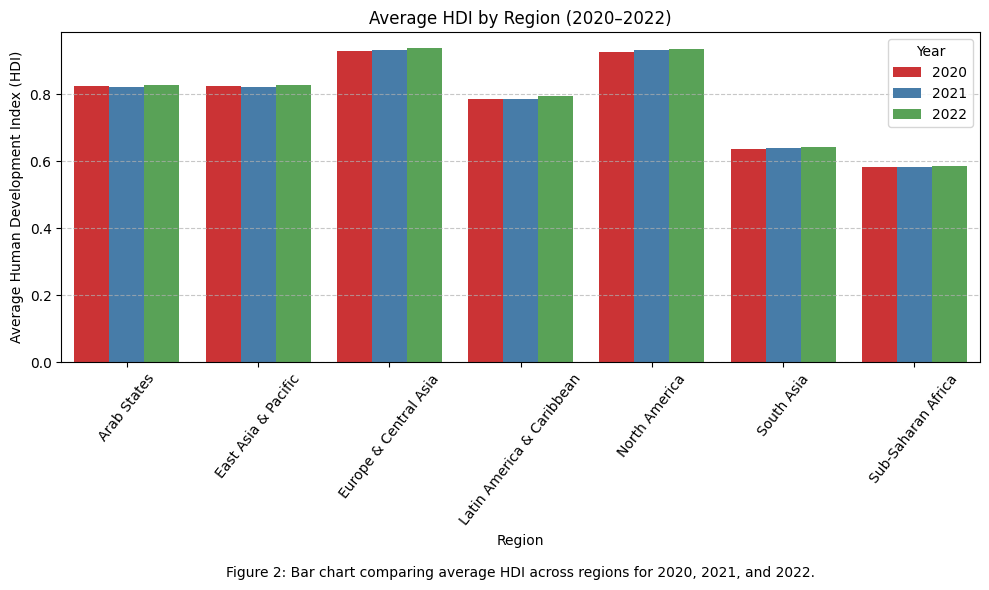

In [485]:
# Visualization 2 (Problem 1B): Bar chart — average HDI by Region and Year (2020–2022)
# Group by region and year
region_avg = (
    hdi_filtered
    .groupby(['region', 'year'])['hdi']
    .mean()
    .reset_index()
)

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=region_avg, x='region', y='hdi', hue='year',palette='Set1')

plt.xlabel('Region\n\nFigure 2: Bar chart comparing average HDI across regions for 2020, 2021, and 2022.')
plt.ylabel('Average Human Development Index (HDI)')
plt.title('Average HDI by Region (2020–2022)')
plt.xticks(rotation=52)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()
plt.show()


**Figure 2 interpretation:** This grouped bar chart summarizes regional average HDI for each year. Regions with consistently taller bars indicate higher human development. Differences between years within a region highlight short-term changes over 2020–2022.

**Box Plot: HDI Distribution for 2020, 2021, and 2022**

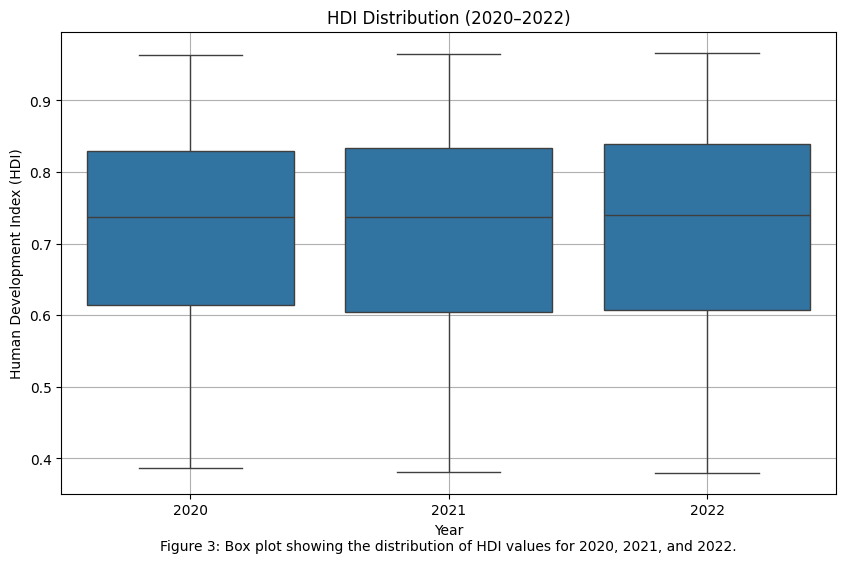

In [486]:

# Filter dataset for 2020, 2021, 2022
hdi_filtered = hdi_1b[hdi_1b['year'].isin([2020, 2021, 2022])]

plt.figure(figsize=(10,6))
sns.boxplot(data=hdi_filtered, x='year', y='hdi')
plt.title('HDI Distribution (2020–2022)')
plt.xlabel('Year\nFigure 3: Box plot showing the distribution of HDI values for 2020, 2021, and 2022.')
plt.ylabel('Human Development Index (HDI)')
plt.grid()
plt.show()

# Observation:
# - Median HDI slightly increases from 2020 to 2022.
# - Spread (IQR) remains relatively stable.
# - Some outliers indicate countries with much lower or higher HDI.


**Figure 3 interpretation:** The box plots show the spread of HDI values each year. A higher median line indicates improvement in typical HDI, while wider boxes/whiskers indicate greater inequality in HDI across countries.

**Scatter Plot: HDI vs. GNI per Capita**

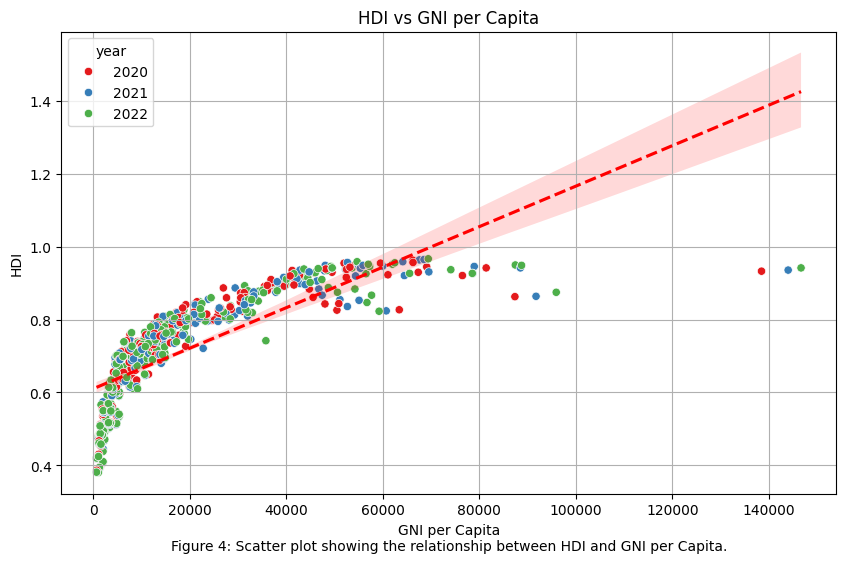

Interpretation:
- HDI generally increases as GNI per Capita increases.
- Countries with very low GNI show more variation in HDI.
- The regression line shows a positive correlation between HDI and GNI per Capita.


In [487]:
# Scatter Plot: HDI vs GNI per Capita
if 'gross_inc_percap' in hdi_1b.columns:
    plt.figure(figsize=(10,6))
    sns.scatterplot(data=hdi_1b, x='gross_inc_percap', y='hdi', hue='year',palette="Set1")
    sns.regplot(data=hdi_1b, x='gross_inc_percap', y='hdi', scatter=False, color='red', line_kws={'linestyle':'--'})
    plt.title('HDI vs GNI per Capita')
    plt.xlabel('GNI per Capita\nFigure 4: Scatter plot showing the relationship between HDI and GNI per Capita.')
    plt.ylabel('HDI')
    plt.grid()
    plt.show()

    # Brief interpretation
    print("Interpretation:")
    print("- HDI generally increases as GNI per Capita increases.")
    print("- Countries with very low GNI show more variation in HDI.")
    print("- The regression line shows a positive correlation between HDI and GNI per Capita.")

else:
    print('GNI per Capita variable not available in the dataset.')

**Figure 4 interpretation:** This scatter plot visualizes how HDI relates to GNI per capita. An upward trend suggests that higher income is generally associated with higher HDI, while scattered points indicate that health and education differences can lead to different HDI at similar income levels.

### **Task 4 :Short Analysis Questions:**

**Which countries show the greatest improvement in HDI from 2020 to 2022?**

Ans: Andorra, Azerbaijan, and Ecuador showed the most significant improvements in HDI during this period. Andorra had the largest increase with a change of +0.041.

In [488]:
hdi_change = (
    hdi_1b
    .pivot(index='country', columns='year', values='hdi')
)

hdi_change['change_2020_2022'] = hdi_change[2022] - hdi_change[2020]

hdi_change.sort_values(by='change_2020_2022', ascending=False).head()


year,2020,2021,2022,change_2020_2022
country,,,,
Andorra,0.843,0.855,0.884,0.041
Azerbaijan,0.722,0.738,0.760,0.038
Ecuador,0.734,0.746,0.765,0.031
Maldives,0.737,0.753,0.762,0.025
Mexico,0.757,0.757,0.781,0.024


**Did any countries experience a decline in HDI? Provide possible reasons.**


Ans: Yes, several countries experienced a decline in HDI. The largest declines were observed in Timor-Leste (-0.067), Ukraine (-0.028), and Afghanistan (-0.026). Possible reasons for these declines during 2020-2022 include:

1.COVID-19 Pandemic: Impacts on healthcare, education, and economic stability.

2.Economic Downturns and Inflation: Global economic shocks, supply chain issues, and rising inflation.

3.Conflict and Political Instability: Direct impacts of conflicts (e.g., in Ukraine) or internal instability.

In [489]:
hdi_change.sort_values(by='change_2020_2022').head()

year,2020,2021,2022,change_2020_2022
country,,,,
Timor-Leste,0.633,0.574,0.566,-0.067
Ukraine,0.762,0.755,0.734,-0.028
Afghanistan,0.488,0.473,0.462,-0.026
Namibia,0.634,0.616,0.610,-0.024
Lebanon,0.742,0.725,0.723,-0.019


**Which region has the highest and lowest average HDI across these three years?**

Ans:Europe & Central Asia has the highest average Human Development Index (HDI), at approximately **0.943**, while Sub-Saharan Africa has the lowest average HDI, at approximately **0.583**.


In [490]:
# Filter data for years 2020–2022
hdi_filtered = hdi_1b[hdi_1b['year'].isin([2020, 2021, 2022])].copy()

#region mapping
region_mapping = {
    # South Asia
    'Afghanistan':'South Asia','Bangladesh':'South Asia','Bhutan':'South Asia',
    'India':'South Asia','Maldives':'South Asia','Nepal':'South Asia',
    'Pakistan':'South Asia','Sri Lanka':'South Asia',

    # East Asia & Pacific
    'China':'East Asia & Pacific','Japan':'East Asia & Pacific','South Korea':'East Asia & Pacific',
    'Indonesia':'East Asia & Pacific','Thailand':'East Asia & Pacific','Vietnam':'East Asia & Pacific',
    'Philippines':'East Asia & Pacific','Malaysia':'East Asia & Pacific','Australia':'East Asia & Pacific',
    'New Zealand':'East Asia & Pacific',

    # Europe & Central Asia
    'United Kingdom':'Europe & Central Asia','Germany':'Europe & Central Asia','France':'Europe & Central Asia',
    'Italy':'Europe & Central Asia','Spain':'Europe & Central Asia','Netherlands':'Europe & Central Asia',
    'Norway':'Europe & Central Asia','Sweden':'Europe & Central Asia','Switzerland':'Europe & Central Asia',

    # Latin America & Caribbean
    'Brazil':'Latin America & Caribbean','Argentina':'Latin America & Caribbean','Chile':'Latin America & Caribbean',
    'Colombia':'Latin America & Caribbean','Mexico':'Latin America & Caribbean','Peru':'Latin America & Caribbean',

    # Sub-Saharan Africa
    'Nigeria':'Sub-Saharan Africa','South Africa':'Sub-Saharan Africa','Kenya':'Sub-Saharan Africa',
    'Ethiopia':'Sub-Saharan Africa','Ghana':'Sub-Saharan Africa','Uganda':'Sub-Saharan Africa',

    # Arab States
    'Saudi Arabia':'Arab States','United Arab Emirates':'Arab States','Qatar':'Arab States',
    'Egypt':'Arab States','Jordan':'Arab States','Oman':'Arab States',

    # North America
    'United States of America':'North America','Canada':'North America'
}

# Create region column
hdi_filtered['region'] = hdi_filtered['country'].map(region_mapping)

# Drop rows where region is not mapped
hdi_filtered = hdi_filtered.dropna(subset=['region'])

In [491]:
# Ensure region column exists and no missing values
hdi_filtered['region'] = hdi_filtered['region'].fillna('Other/Unknown')

# Compute average HDI per region across 2020–2022
region_avg_3yrs = (
    hdi_filtered
    .groupby('region')['hdi']
    .mean()
    .sort_values(ascending=False)
)

print(region_avg_3yrs)

# Identify highest and lowest regions
highest_region = region_avg_3yrs.idxmax()
lowest_region = region_avg_3yrs.idxmin()

print(f"Highest Average HDI (2020–2022): {highest_region} (average HDI ≈ {region_avg_3yrs.max():.3f})")
print(f"Lowest Average HDI (2020–2022): {lowest_region} (average HDI ≈ {region_avg_3yrs.min():.3f})")


region
Europe & Central Asia        0.933741
North America                0.932333
East Asia & Pacific          0.825417
Arab States                  0.825000
Latin America & Caribbean    0.789389
South Asia                   0.639583
Sub-Saharan Africa           0.583222
Name: hdi, dtype: float64
Highest Average HDI (2020–2022): Europe & Central Asia (average HDI ≈ 0.934)
Lowest Average HDI (2020–2022): Sub-Saharan Africa (average HDI ≈ 0.583)


In [492]:
#average HDI per region across 2020–2022
region_avg_3yrs = (
    hdi_filtered
    .groupby('region')['hdi']
    .mean()
    .sort_values(ascending=False)
)

print(region_avg_3yrs)

# Identify highest and lowest regions
highest_region = region_avg_3yrs.idxmax()
lowest_region = region_avg_3yrs.idxmin()

print(f"Highest Average HDI (2020–2022): {highest_region} (average HDI ≈ {region_avg_3yrs.max():.3f})")
print(f"Lowest Average HDI (2020–2022): {lowest_region} (average HDI ≈ {region_avg_3yrs.min():.3f})")


region
Europe & Central Asia        0.933741
North America                0.932333
East Asia & Pacific          0.825417
Arab States                  0.825000
Latin America & Caribbean    0.789389
South Asia                   0.639583
Sub-Saharan Africa           0.583222
Name: hdi, dtype: float64
Highest Average HDI (2020–2022): Europe & Central Asia (average HDI ≈ 0.934)
Lowest Average HDI (2020–2022): Sub-Saharan Africa (average HDI ≈ 0.583)


In [493]:
print("Average HDI by Year (2020-2022):")
display(hdi_1b.groupby('year')['hdi'].mean().reset_index())

Average HDI by Year (2020-2022):


,year,hdi
0,2020,0.720897
1,2021,0.720039
2,2022,0.722887


In [494]:
print("Yearly Averages of HDI Components (2020-2022):")
key_components = ['life_expectancy', 'expec_yr_school', 'mean_yr_school', 'gross_inc_percap']
display(hdi_1b.groupby('year')[key_components].mean().reset_index())

Yearly Averages of HDI Components (2020-2022):


,year,life_expectancy,expec_yr_school,mean_yr_school,gross_inc_percap
0,2020,71.764494,13.472248,8.992894,19159.634687
1,2021,71.214626,13.532111,9.004836,20078.173639
2,2022,71.791847,13.514038,8.967164,20722.658911


From 2020 to 2022, global HDI trends were strongly influenced by the COVID-19 pandemic, economic shifts, and geopolitical conflicts. The global HDI declined slightly in 2021 due to the pandemic’s immediate effects most notably a sharp drop in life expectancy caused by excess mortality and strained healthcare systems before showing a modest recovery in 2022 as countries adapted and economies reopened. Education indicators experienced minor fluctuations, reflecting disruptions from school closures, remote learning challenges, and unequal access to technology. In contrast, GNI per capita increased steadily, signaling economic recovery supported by government interventions, although significant inequalities persisted between countries. Geopolitical events, particularly the war in Ukraine and political instability in countries such as Afghanistan, led to localized HDI declines, while some nations, including Andorra, Azerbaijan, and Ecuador, showed improvements. Overall, this period highlights the vulnerability of human development to global shocks and the uneven pace of recovery across different countries.

# **4 Problem 2 Advanced HDI Exploration**


### **Task 1. Create South Asia Subset:**

In [495]:
#Defining list of South Asian countries
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]

#Filtering the HDI dataset to include only these countries.
hdi_sa = hdi_df[hdi_df['country'].isin(south_asia)].copy()

#Saving the filtered dataset as HDI SouthAsia.csv
file_path = '/content/drive/MyDrive/CAI/HDI problem1B.csv'
hdi_sa.to_csv(file_path, index=False)
print("Filtered dataset saved as HDI_SouthAsia.csv")

Filtered dataset saved as HDI_SouthAsia.csv


### **Task 2:Composite Development Score:**

In [496]:
#Create a new metric
hdi_sa['Composite Score'] = (
    0.30 * hdi_sa['life_expectancy'] +
    0.30 * hdi_sa['gross_inc_percap']
)

In [497]:
#Ranking South Asian countries based on Composite Score.
country_mean=hdi_sa.groupby('country')['Composite Score'].mean().sort_values(ascending=False)
country_mean


,Composite Score
country,
Maldives,4154.252676
Sri Lanka,2502.612949
Bhutan,1878.321569
Pakistan,1184.282350
India,1151.101140
Bangladesh,1042.583232
Nepal,779.209282
Afghanistan,555.454413


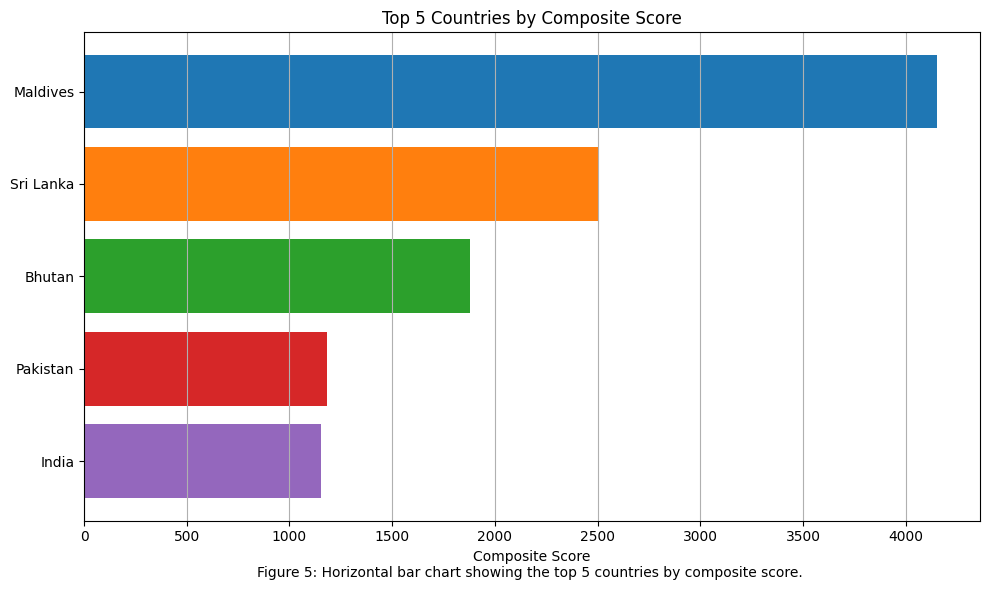

In [498]:
#Plotting the top 5 countries in a horizontal bar chart.
plt.figure(figsize=(10, 6))
top_5 = country_mean.head(5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.barh(top_5.index, top_5.values, color=colors)
plt.title('Top 5 Countries by Composite Score')
plt.xlabel('Composite Score\nFigure 5: Horizontal bar chart showing the top 5 countries by composite score. ')
plt.gca().invert_yaxis()  # highest value on top
plt.grid(axis='x')
plt.tight_layout()
plt.show()


**Figure 5 interpretation:** This chart ranks South Asian countries using the Composite Score (based on life expectancy and income indices). Differences from HDI ranking can occur because HDI also includes education components, which are not part of this simplified composite metric.

In [499]:
 #filtering hdi_sa for the year 2022 to ensure we are working with the correct data.
hdi_southasia_2022 = hdi_sa[hdi_sa['year'] == 2022].copy()

# index values
hdi_southasia_2022['Life_Expectancy_Index'] = (
    (hdi_southasia_2022['life_expectancy'] - hdi_southasia_2022['life_expectancy'].min()) /
    (hdi_southasia_2022['life_expectancy'].max() - hdi_southasia_2022['life_expectancy'].min())
)

hdi_southasia_2022['GNI_Index'] = (
    (hdi_southasia_2022['gross_inc_percap'] - hdi_southasia_2022['gross_inc_percap'].min()) /
    (hdi_southasia_2022['gross_inc_percap'].max() - hdi_southasia_2022['gross_inc_percap'].min())
)
hdi_southasia_2022['Composite Score'] = (
    0.30 * hdi_southasia_2022['Life_Expectancy_Index'] +
    0.30 * hdi_southasia_2022['GNI_Index']
)

In [500]:
# Ranking South Asian countries based on Composite Score for 2022.
ranked_by_composite_score = hdi_southasia_2022.sort_values(
    by='Composite Score', ascending=False
)
print("Countries ranked by Composite Score (2022):")

display(ranked_by_composite_score[['country', 'Composite Score', 'hdi']])

Countries ranked by Composite Score (2022):


,country,Composite Score,hdi
3530,Maldives,0.600000,0.762
5477,Sri Lanka,0.410342,0.780
659,Bhutan,0.315326,0.681
461,Bangladesh,0.269390,0.670
2573,India,0.177463,0.644
4091,Nepal,0.173122,0.601
4388,Pakistan,0.128527,0.540
32,Afghanistan,0.000000,0.462


In [501]:
# Sorting HDI for 2022
ranked_by_hdi = hdi_southasia_2022.sort_values(by='hdi', ascending=False)
print("\nCountries ranked by HDI (2022):")

display(ranked_by_hdi[['country', 'hdi', 'Composite Score']])


Countries ranked by HDI (2022):


,country,hdi,Composite Score
5477,Sri Lanka,0.780,0.410342
3530,Maldives,0.762,0.600000
659,Bhutan,0.681,0.315326
461,Bangladesh,0.670,0.269390
2573,India,0.644,0.177463
4091,Nepal,0.601,0.173122
4388,Pakistan,0.540,0.128527
32,Afghanistan,0.462,0.000000


In 2022, South Asian rankings show notable differences between Composite Score and HDI. Both place Sri Lanka and Maldives at the top and Afghanistan at the bottom, but the order differs: Maldives leads the Composite Score (~6309) due to high GNI per capita, while Sri Lanka tops HDI (0.780 vs. 0.762). Bhutan ranks third in both, and India surpasses Bangladesh in Composite Score despite a lower HDI. Pakistan, Nepal, and Afghanistan remain near the bottom in both metrics. These differences occur because the Composite Score averages raw HDI, life expectancy, and GNI per capita values—making it sensitive to high income—whereas HDI uses normalized indices and geometric means to account for diminishing returns, providing a more balanced measure of human development.

### **Task 3: Outlier Detection**

HDI outliers:
Empty DataFrame
Columns: [country, hdi]
Index: []

GNI outliers:
        country  gross_inc_percap
3511   Maldives       14543.14634
3512   Maldives       15287.20714
3514   Maldives       16391.40757
3515   Maldives       14162.42816
3516   Maldives       15423.81910
3517   Maldives       14050.92438
3518   Maldives       14363.23615
3519   Maldives       15300.31364
3520   Maldives       15355.44089
3521   Maldives       15648.36655
3522   Maldives       16410.16419
3523   Maldives       16414.93039
3524   Maldives       16911.45422
3525   Maldives       17474.64201
3526   Maldives       18055.72465
3527   Maldives       18679.92536
3529   Maldives       16857.60546
3530   Maldives       18846.79219
5473  Sri Lanka       13405.80369


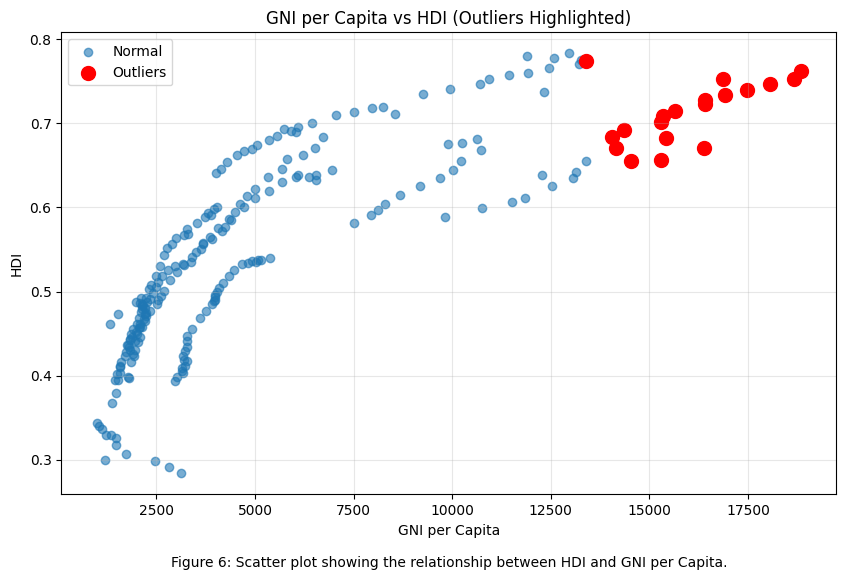

In [502]:
def find_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

# Find outliers
hdi_outliers = find_outliers(hdi_sa, 'hdi')
gni_outliers = find_outliers(hdi_sa, 'gross_inc_percap')

print("HDI outliers:")
print(hdi_outliers[['country', 'hdi']])

print("\nGNI outliers:")
print(gni_outliers[['country', 'gross_inc_percap']])

# Scatter plot
plt.figure(figsize=(10, 6))

# Plot all points
plt.scatter(hdi_sa['gross_inc_percap'], hdi_sa['hdi'], alpha=0.6, label='Normal')

# Highlight outliers
outliers = pd.concat([hdi_outliers, gni_outliers]).drop_duplicates()
plt.scatter(outliers['gross_inc_percap'], outliers['hdi'], color='red', s=100, label='Outliers')

plt.title('GNI per Capita vs HDI (Outliers Highlighted)')
plt.xlabel('GNI per Capita\n\nFigure 6: Scatter plot showing the relationship between HDI and GNI per Capita.')
plt.ylabel('HDI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Figure 6 interpretation:** Outliers represent countries that deviate strongly from the typical HDI–income relationship in South Asia. These can reflect unusually high income relative to HDI, unusually high HDI relative to income, or data irregularities.

Brief discussion

 Countries highlighted in red are outliers either in HDI, GNI per Capita, or both.Outliers typically stand out because they have unusually high or low HDI relative to their GNI,These may indicate very wealthy countries with low development, or low-income countries with unusually high human development.

### **Task 4: Exploring metric Relationships**

HDI vs Life Expectancy: r = 0.959
HDI vs Gender Development: r = 0.866


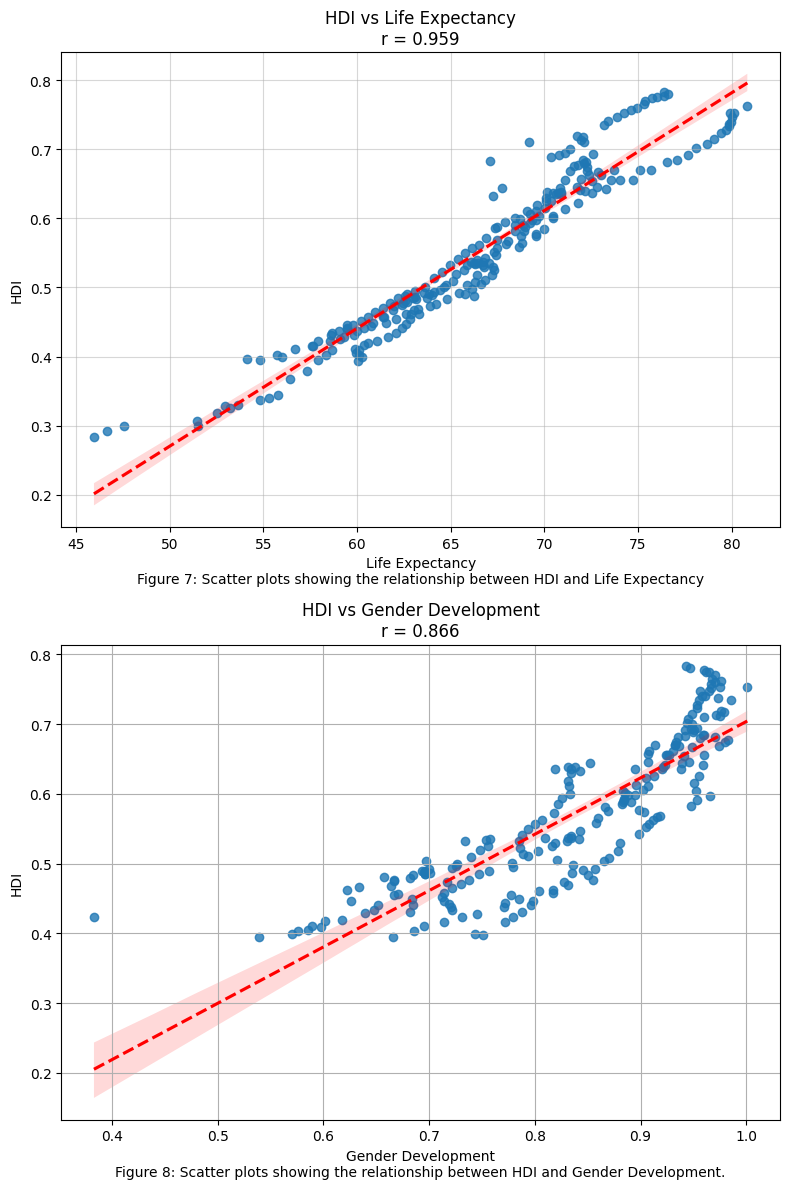


Discussion:
- Life Expectancy is more strongly correlated with HDI (r = 0.959) than Gender Development (r = 0.866).
- The metric with the weaker correlation shows a weaker linear relationship with HDI, indicating it contributes less to overall variation in HDI.


In [503]:
# Calculating correlations
corr1 = hdi_sa['hdi'].corr(hdi_sa['life_expectancy'])
corr2 = hdi_sa['hdi'].corr(hdi_sa['gender_development'])

print(f"HDI vs Life Expectancy: r = {corr1:.3f}")
print(f"HDI vs Gender Development: r = {corr2:.3f}")

# Createing scatter plots with trendlines
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 12))

# Scatter + trendline for Life Expectancy
sns.regplot(x='life_expectancy', y='hdi', data=hdi_sa, ax=ax1, line_kws={'color':'red', 'linestyle':'--'})
ax1.set_title(f'HDI vs Life Expectancy\nr = {corr1:.3f}')
ax1.set_xlabel('Life Expectancy\nFigure 7: Scatter plots showing the relationship between HDI and Life Expectancy')
ax1.set_ylabel('HDI')
ax1.grid(True, alpha=0.5)

# Scatter + trendline for Gender Development
sns.regplot(x='gender_development', y='hdi', data=hdi_sa, ax=ax2, line_kws={'color':'red', 'linestyle':'--'})
ax2.set_title(f'HDI vs Gender Development\nr = {corr2:.3f}')
ax2.set_xlabel('Gender Development\nFigure 8: Scatter plots showing the relationship between HDI and Gender Development.')
ax2.set_ylabel('HDI')

plt.grid()
plt.tight_layout()
plt.show()

# Discussion
print("\nDiscussion:")
if abs(corr1) > abs(corr2):
    print(f"- Life Expectancy is more strongly correlated with HDI (r = {corr1:.3f}) than Gender Development (r = {corr2:.3f}).")
else:
    print(f"- Gender Development is more strongly correlated with HDI (r = {corr2:.3f}) than Life Expectancy (r = {corr1:.3f}).")

print("- The metric with the weaker correlation shows a weaker linear relationship with HDI, indicating it contributes less to overall variation in HDI.")


### **Task 5: Gap Analysis**

Top 3 Positive Gaps:


,country,GNI_HDI_Gap
3530,Maldives,18846.03019
5477,Sri Lanka,11898.71847
659,Bhutan,10624.19288



Top 3 Negative Gaps:


,country,GNI_HDI_Gap
32,Afghanistan,1334.743733
4091,Nepal,4024.953685
4388,Pakistan,5373.730423


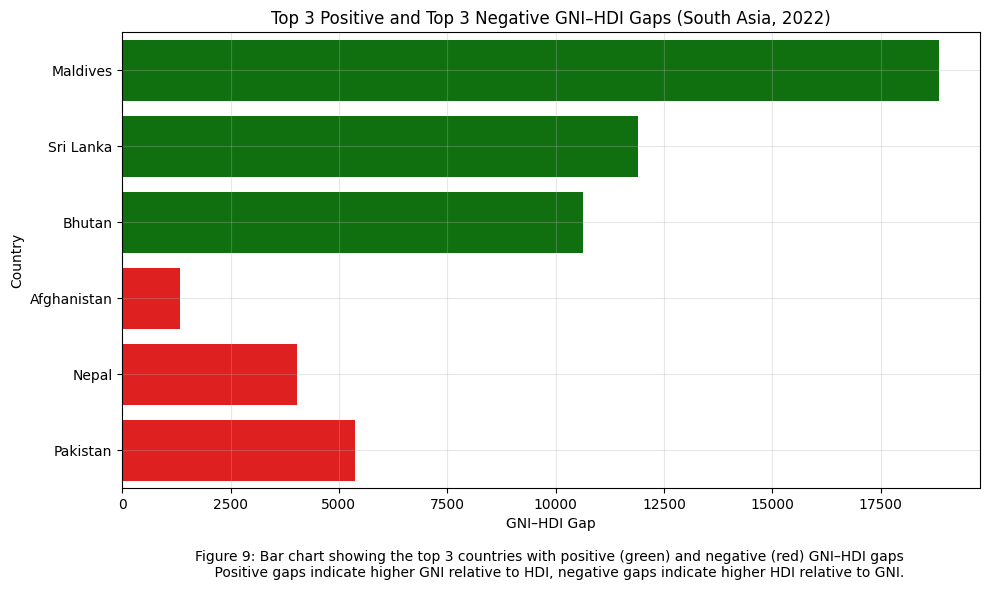

In [504]:
# New metric creation
hdi_southasia_2022['GNI_HDI_Gap'] = hdi_southasia_2022['gross_inc_percap'] - hdi_southasia_2022['hdi']

# Ranking South Asian countries
gap_desc = hdi_southasia_2022.sort_values(by='GNI_HDI_Gap', ascending=False)[['country', 'GNI_HDI_Gap']]
gap_asc = hdi_southasia_2022.sort_values(by='GNI_HDI_Gap', ascending=True)[['country', 'GNI_HDI_Gap']]

print("Top 3 Positive Gaps:")
display(gap_desc.head(3))

print("\nTop 3 Negative Gaps:")
display(gap_asc.head(3))

# Plotting top 3 positive and negative gaps
top_positive = gap_desc.head(3)
top_negative = gap_asc.head(3)
gap_df = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10,6))
sns.barplot(
    data=gap_df,
    x='GNI_HDI_Gap',
    y='country',
    hue='country',
    palette=['green']*3 + ['red']*3  # positive green, negative red
)
plt.title("Top 3 Positive and Top 3 Negative GNI–HDI Gaps (South Asia, 2022)")
plt.xlabel("""GNI–HDI Gap\n\nFigure 9: Bar chart showing the top 3 countries with positive (green) and negative (red) GNI–HDI gaps \n    Positive gaps indicate higher GNI relative to HDI, negative gaps indicate higher HDI relative to GNI.""")
plt.ylabel("Country")
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()


Discussion:
The GNI–HDI Gap highlights differences between economic wealth and human development in South Asian countries. Countries with positive gaps, where GNI per Capita is higher than HDI would suggest, indicate that income wealth does not always fully translate into higher human development outcomes. Conversely, countries with negative gaps show relatively high HDI despite lower income, reflecting effective investments in health, education, and living standards. These disparities emphasize the importance of looking beyond income alone to assess overall development.

# **5 Problem 3 Comparative Regional Analysis: South Asia vs Middle East**


### **Task1 : Create Middle East Subset:**

In [505]:
# Define country groups
south_asia = ["Afghanistan", "Bangladesh", "Bhutan", "India", "Maldives", "Nepal", "Pakistan", "Sri Lanka"]
middle_east = ["Bahrain", "Iran", "Iraq", "Israel", "Jordan", "Kuwait",
               "Lebanon", "Oman", "Palestine", "Qatar", "Saudi Arabia",
               "Syria", "United Arab Emirates", "Yemen"]


In [506]:
# Load dataset (from Problem 1B)
hdi_2022_df = pd.read_csv("/content/drive/MyDrive/CAI/HDI_problem1B.csv")

In [507]:
# Filter subsets
sa_2020_22 = hdi_2022_df[hdi_2022_df['country'].isin(south_asia)]
me_2020_22 = hdi_2022_df[hdi_2022_df['country'].isin(middle_east)]

In [508]:
# Save subsets to CSV
sa_2020_22.to_csv("/content/drive/MyDrive/CAI/HDI_SouthAsia_2020_2022.csv", index=False)
me_2020_22.to_csv("/content/drive/MyDrive/CAI/HDI_MiddleEast_2020_2022.csv", index=False)
print("\nDone! Subsets saved as CSV files.")


Done! Subsets saved as CSV files.


### **Task 2: Descriptive Statistics**


In [509]:
# Mean and standard deviation of HDI
mean_sa = sa_2020_22['hdi'].mean()
std_sa = sa_2020_22['hdi'].std()

mean_me = me_2020_22['hdi'].mean()
std_me = me_2020_22['hdi'].std()

print(f"South Asia HDI: Mean = {mean_sa:.3f}, Std = {std_sa:.3f}")
print(f"Middle East HDI: Mean = {mean_me:.3f}, Std = {std_me:.3f}")

South Asia HDI: Mean = 0.640, Std = 0.098
Middle East HDI: Mean = 0.789, Std = 0.141


In [510]:
# Identifying which region performs better on average
if mean_sa > mean_me:
    print("South Asia performs better on average HDI.")
elif mean_sa < mean_me:
    print("Middle East performs better on average HDI.")
else:
    print("Both regions have the same average HDI.")


Middle East performs better on average HDI.


### **Task 3:Top and Bottom Performers**

In [511]:
#Aggregating HDI by country over 2020–2022
sa_avg = sa_2020_22.groupby('country')['hdi'].mean().reset_index()
me_avg = me_2020_22.groupby('country')['hdi'].mean().reset_index()

#Identifying Top and Bottom 3 Countries
sa_top3 = sa_avg.nlargest(3, 'hdi')
sa_bottom3 = sa_avg.nsmallest(3, 'hdi')

me_top3 = me_avg.nlargest(3, 'hdi')
me_bottom3 = me_avg.nsmallest(3, 'hdi')

print("South Asia Top 3:\n", sa_top3)
print("South Asia Bottom 3:\n", sa_bottom3)
print("Middle East Top 3:\n", me_top3)
print("Middle East Bottom 3:\n", me_bottom3)


South Asia Top 3:
      country       hdi
7  Sri Lanka  0.780000
4   Maldives  0.750667
2     Bhutan  0.677667
South Asia Bottom 3:
        country       hdi
0  Afghanistan  0.474333
6     Pakistan  0.537667
5        Nepal  0.595000
Middle East Top 3:
                 country       hdi
9  United Arab Emirates  0.932667
2                Israel  0.910667
0               Bahrain  0.885333
Middle East Bottom 3:
     country       hdi
10    Yemen  0.426333
1      Iraq  0.667000
5   Lebanon  0.730000


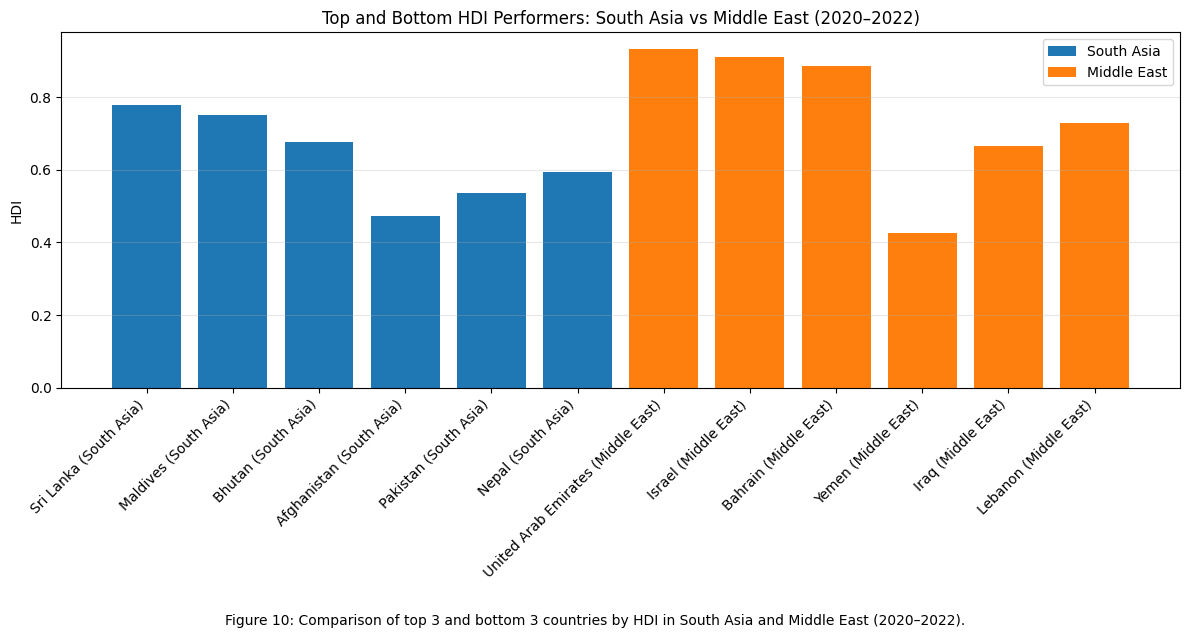

In [512]:


# Combine top and bottom performers for each region
sa_top_bottom = pd.concat([sa_top3, sa_bottom3])
me_top_bottom = pd.concat([me_top3, me_bottom3])

# Add a column to identify the region
sa_top_bottom['region'] = 'South Asia'
me_top_bottom['region'] = 'Middle East'

# Combine both regions
comparison_df = pd.concat([sa_top_bottom, me_top_bottom])

# Plotting
plt.figure(figsize=(12, 6))
for region in comparison_df['region'].unique():
    subset = comparison_df[comparison_df['region'] == region]
    plt.bar(subset['country'] + " (" + region + ")", subset['hdi'], label=region)

plt.xticks(rotation=45, ha='right')
plt.ylabel('HDI')
plt.title('Top and Bottom HDI Performers: South Asia vs Middle East (2020–2022)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.figtext(0.5, -0.05,
            "Figure 10: Comparison of top 3 and bottom 3 countries by HDI in South Asia and Middle East (2020–2022).",
            wrap=True, horizontalalignment='center', fontsize=10)
plt.show()


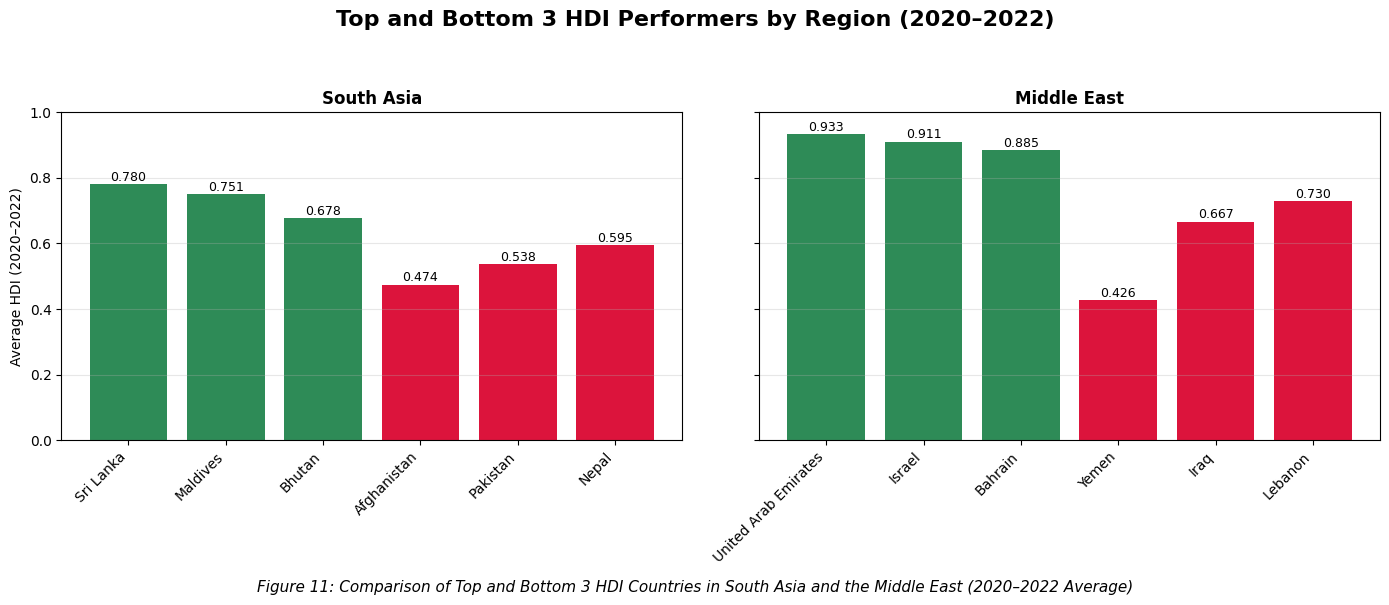

In [513]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

regions = [
    (axes[0], sa_top3, sa_bottom3, 'South Asia'),
    (axes[1], me_top3, me_bottom3, 'Middle East')
]

for ax, top, bottom, region in regions:
    data = pd.concat([top, bottom], ignore_index=True)

    colors = ['#2E8B57'] * 3 + ['#DC143C'] * 3  # Green = Top, Red = Bottom

    bars = ax.bar(
        range(len(data)),
        data['hdi'],
        color=colors
    )

    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['country'], rotation=45, ha='right')
    ax.set_title(region, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

    # Value labels
    for i, value in enumerate(data['hdi']):
        ax.text(i, value + 0.01, f'{value:.3f}', ha='center', fontsize=9)

axes[0].set_ylabel('Average HDI (2020–2022)')

plt.suptitle(
    'Top and Bottom 3 HDI Performers by Region (2020–2022)',
    fontsize=16,
    fontweight='bold'
)

fig.text(
    0.5, 0.01,
    'Figure 11: Comparison of Top and Bottom 3 HDI Countries in South Asia and the Middle East (2020–2022 Average)',
    ha='center',
    fontsize=11,
    style='italic'
)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


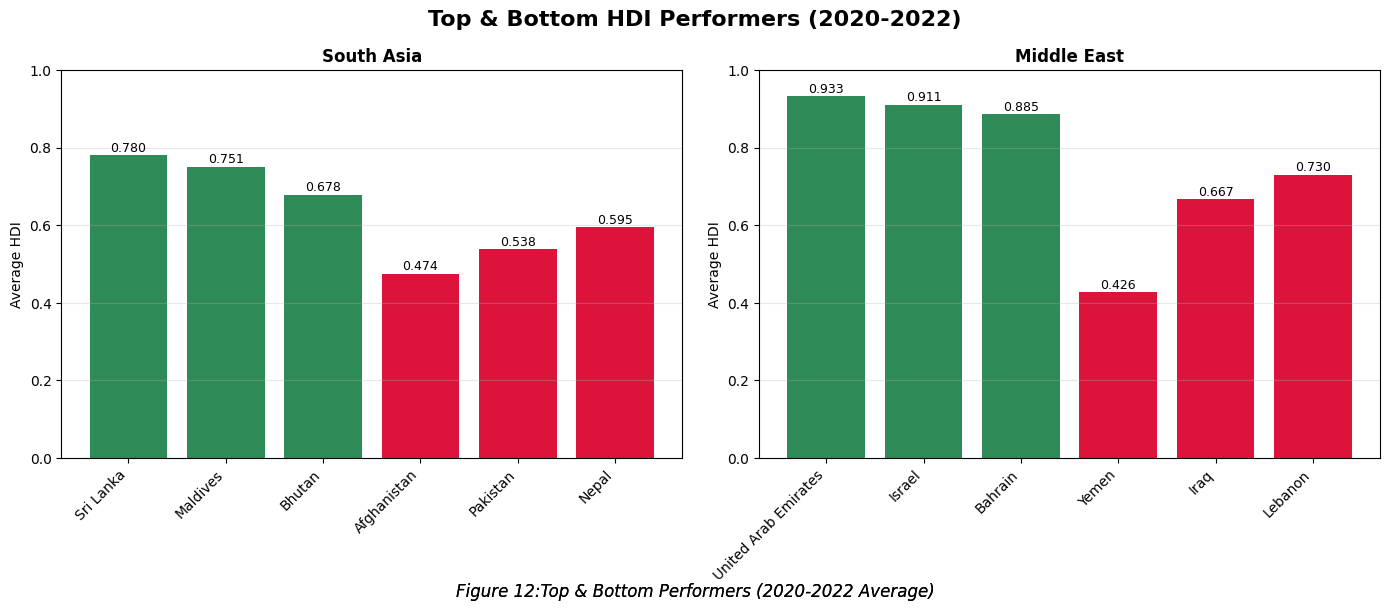

In [514]:
#bar chart comparing these top and bottom performers across the two regions

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top, bottom, region in [(axes[0], sa_top3, sa_bottom3, 'South Asia'),
                                 (axes[1], me_top3, me_bottom3, 'Middle East')]:
    data = pd.concat([top, bottom])

    # Create bar plot
    bars = ax.bar(range(len(data)), data['hdi'], color=['#2E8B57']*3 + ['#DC143C']*3)

    # Set ticks and labels properly
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data['country'], rotation=45, ha='right')

    ax.set_title(region, fontweight='bold')
    ax.set_ylabel('Average HDI')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    fig.text(0.5, 0.001, 'Figure 12:Top & Bottom Performers (2020-2022 Average)',
         ha='center', fontsize=12, style='italic')

    # Add value labels
    for i, hdi in enumerate(data['hdi']):
        ax.text(i, hdi + 0.01, f'{hdi:.3f}', ha='center', fontsize=9)

plt.suptitle('Top & Bottom HDI Performers (2020-2022)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **Task 4: Metric Comparisons:**


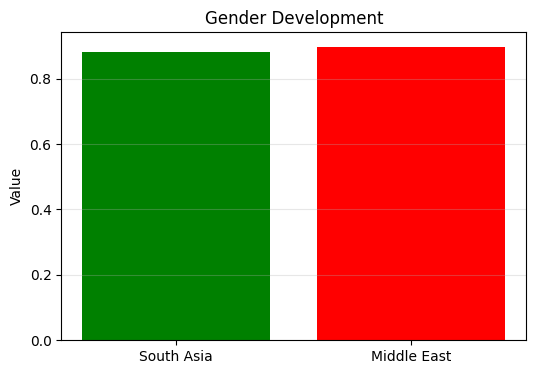

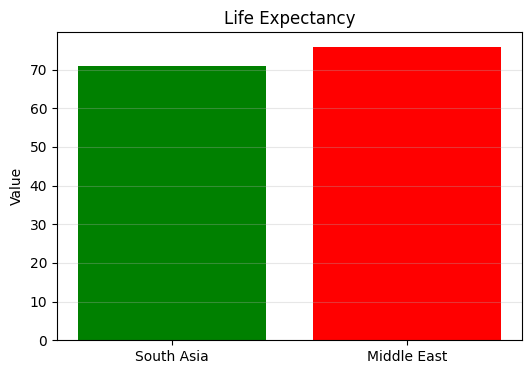

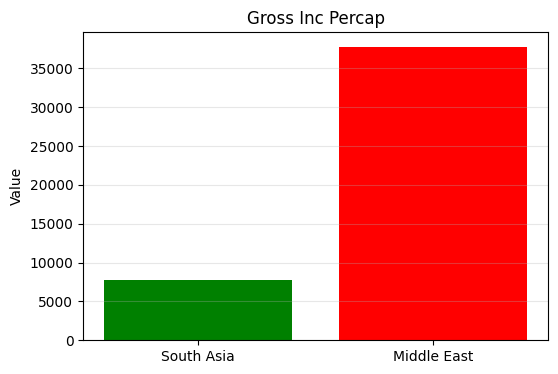

In [515]:
import pandas as pd
import matplotlib.pyplot as plt

# Metrics
metrics = ['gender_development', 'life_expectancy', 'gross_inc_percap']

# Regional averages
sa_metrics = sa_2020_22[metrics].mean()
me_metrics = me_2020_22[metrics].mean()

# Create metric_df
metric_data = []
for metric_name in metrics:
    metric_data.append({'Metric': metric_name, 'Value': sa_metrics[metric_name], 'Region': 'South Asia'})
    metric_data.append({'Metric': metric_name, 'Value': me_metrics[metric_name], 'Region': 'Middle East'})
metric_df = pd.DataFrame(metric_data)

# Loop through each metric and plot separately
for metric in metrics:
    plt.figure(figsize=(6, 4))

    plt.bar(
        ['South Asia', 'Middle East'],
        [sa_metrics[metric], me_metrics[metric]],
        color=['green', 'red']
    )

    plt.title(metric.replace('_', ' ').title())
    plt.ylabel('Value')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

In [516]:
# Simple disparity calculation
sa_vals = metric_df[metric_df['Region'] == 'South Asia'].set_index('Metric')['Value']
me_vals = metric_df[metric_df['Region'] == 'Middle East'].set_index('Metric')['Value']
disparities = me_vals - sa_vals
print("Disparities:")
print(disparities)

greatest = disparities.abs().idxmax()
print(f"\nGreatest disparity: {greatest} ({disparities[greatest]:.2f} difference)")

Disparities:
Metric
gender_development        0.015087
life_expectancy           4.885371
gross_inc_percap      29984.260588
Name: Value, dtype: float64

Greatest disparity: gross_inc_percap (29984.26 difference)


In [517]:
# Simple disparity calculation
sa_vals = metric_df[metric_df['Region'] == 'South Asia'].set_index('Metric')['Value']
me_vals = metric_df[metric_df['Region'] == 'Middle East'].set_index('Metric')['Value']
disparities = me_vals - sa_vals
print("Disparities:")
print(disparities)

greatest = disparities.abs().idxmax()
print(f"\nGreatest disparity: {greatest} ({disparities[greatest]:.2f} difference)")

Disparities:
Metric
gender_development        0.015087
life_expectancy           4.885371
gross_inc_percap      29984.260588
Name: Value, dtype: float64

Greatest disparity: gross_inc_percap (29984.26 difference)


### **Task:5 HDI Disparity**

In [518]:
#Compute the range (max – min) of HDI for each region.
sa_range = sa_2020_22['hdi'].max() - sa_2020_22['hdi'].min()
me_range = me_2020_22['hdi'].max() - me_2020_22['hdi'].min()

print(f"South Asia HDI range: {sa_range:.3f}")
print(f"Middle East HDI range: {me_range:.3f}")

South Asia HDI range: 0.321
Middle East HDI range: 0.513


In [519]:
#Compute the coefficient of variation (CV = std/mean) for HDI.
sa_cv = sa_2020_22['hdi'].std() / sa_2020_22['hdi'].mean()
me_cv = me_2020_22['hdi'].std() / me_2020_22['hdi'].mean()

print(f"South Asia HDI CV: {sa_cv:.3f}")
print(f"Middle East HDI CV: {me_cv:.3f}")

South Asia HDI CV: 0.154
Middle East HDI CV: 0.179


In [520]:
#Identify which region exhibits more variation in HDI.
if sa_cv > me_cv:
    print("More variation: South Asia")
else:
    print("More variation: Middle East")

More variation: Middle East


### **Task 6: Correlation Analysis**

In [521]:
#correlations of HDI
sa_corr = sa_2020_22[['hdi','gender_development','life_expectancy']].corr()
sa_corr

,hdi,gender_development,life_expectancy
hdi,1.000000,0.874218,0.938764
gender_development,0.874218,1.000000,0.853780
life_expectancy,0.938764,0.853780,1.000000


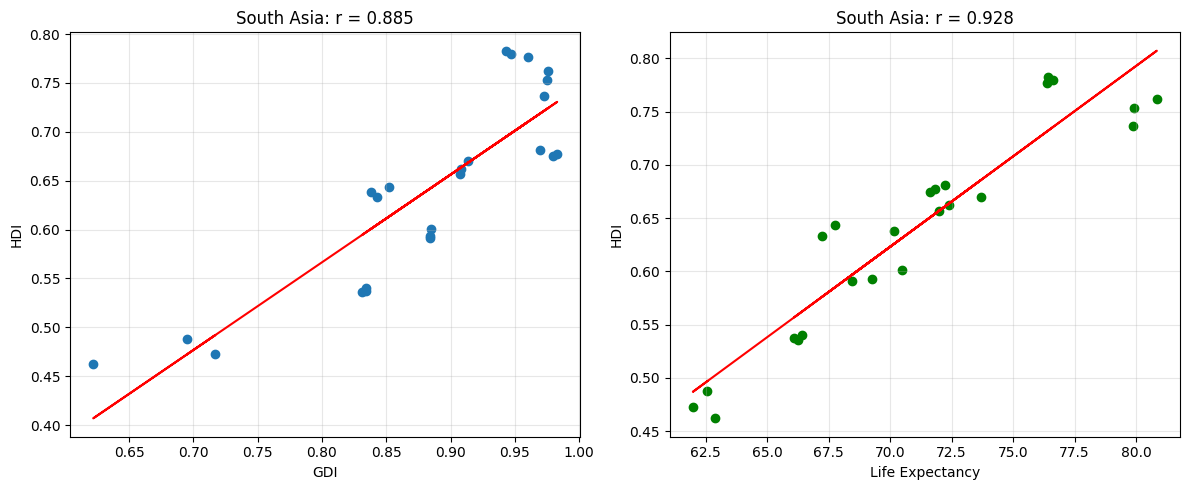

In [522]:
#Create scatter plots with trendlines for each correlation.
plt.figure(figsize=(12, 5))

# SOUTH ASIA
# HDI vs Gender
plt.subplot(1, 2, 1)
x = sa_2020_22['gender_development']
y = sa_2020_22['hdi']
plt.scatter(x, y)
z = np.polyfit(x, y, 1)  # Get line
plt.plot(x, np.poly1d(z)(x), 'r-')
plt.title('South Asia: r = 0.885')
plt.xlabel('GDI')
plt.ylabel('HDI')
plt.grid(True, alpha=0.3)
# HDI vs Life
plt.subplot(1, 2, 2)
x = sa_2020_22['life_expectancy']
y = sa_2020_22['hdi']
plt.scatter(x, y, color='green')
z = np.polyfit(x, y, 1)
plt.plot(x, np.poly1d(z)(x), 'r-')
plt.title('South Asia: r = 0.928')
plt.xlabel('Life Expectancy')
plt.ylabel('HDI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

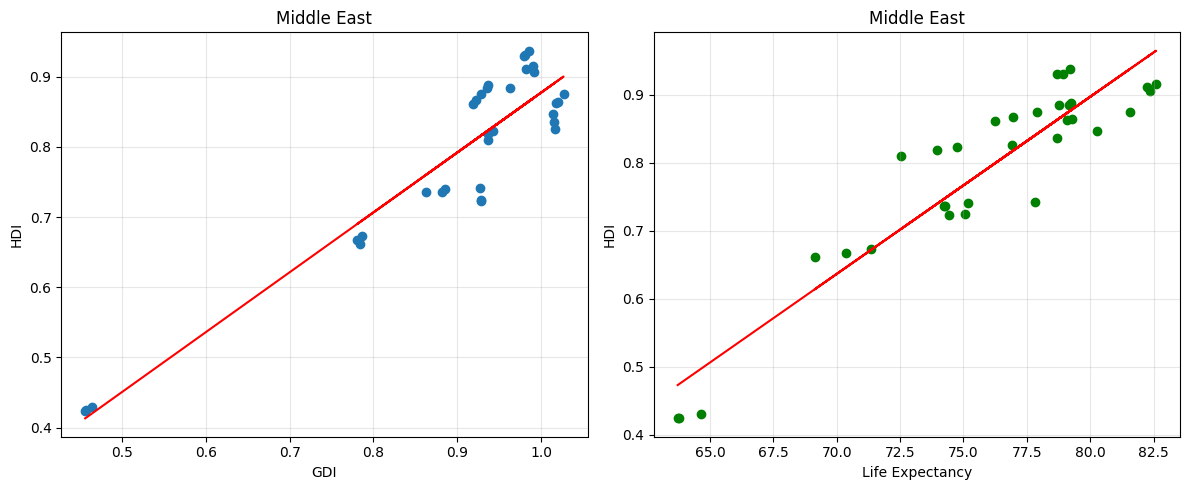

In [523]:

plt.figure(figsize=(12, 5))

# Middle East
# HDI vs Gender
plt.subplot(1, 2, 1)
x = me_2020_22['gender_development']
y = me_2020_22['hdi']
plt.scatter(x, y)
z = np.polyfit(x, y, 1)
plt.plot(x, np.poly1d(z)(x), 'r-')
plt.title('Middle East')
plt.xlabel('GDI')
plt.ylabel('HDI')
plt.grid(True, alpha=0.3)
# HDI vs Life
plt.subplot(1, 2, 2)
x = me_2020_22['life_expectancy']
y = me_2020_22['hdi']
plt.scatter(x, y, color='green')
z = np.polyfit(x, y, 1)
plt.plot(x, np.poly1d(z)(x), 'r-')
plt.title('Middle East')
plt.xlabel('Life Expectancy')
plt.ylabel('HDI')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Interpret the strength and direction of these relationships.



SOUTH ASIA RESULTS

Both relationships show strong positive correlations in South Asia. The HDI-Gender Development link (r=0.885) indicates that as gender equality improves, human development rises significantly. The even stronger HDI-Life Expectancy relationship (r=0.928) shows that longer lifespans are closely tied to higher development scores. Countries with better health and gender equality consistently achieve superior development outcomes.

MIDDLE EAST RESULTS

The Middle East demonstrates very strong positive correlations, slightly exceeding South Asia. With HDI-Gender Development at r≈0.937 and HDI-Life Expectancy at r≈0.945, both relationships show near-perfect alignment. The tighter data clustering indicates more consistent patterns across countries, where improvements in gender equality and health reliably translate to higher human development.

KEY INSIGHTS

Life expectancy emerges as the strongest predictor of HDI in both regions. The consistent positive direction confirms that development indicators move together—improvements in one area accompany gains in others. These strong correlations validate that gender equality and health outcomes are fundamental components of human development, with the Middle East showing slightly more uniform development patterns than South Asia.



### **Task 7:Outlier Detection:**


In [524]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] < Q1 - 1.5*IQR) | (df[column] > Q3 + 1.5*IQR)]

sa_outliers = detect_outliers(sa_2020_22, 'hdi')
me_outliers = detect_outliers(me_2020_22, 'hdi')

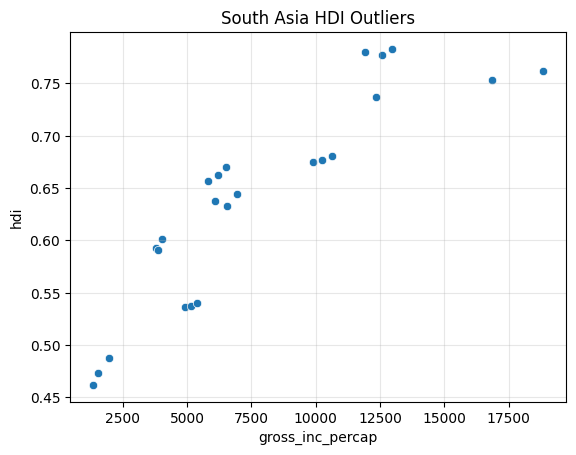

In [525]:
sns.scatterplot(data=sa_2020_22, x='gross_inc_percap', y='hdi')
sns.scatterplot(data=sa_outliers, x='gross_inc_percap', y='hdi', color='red')
plt.title("South Asia HDI Outliers")
plt.grid(True, alpha=0.3)
plt.show()

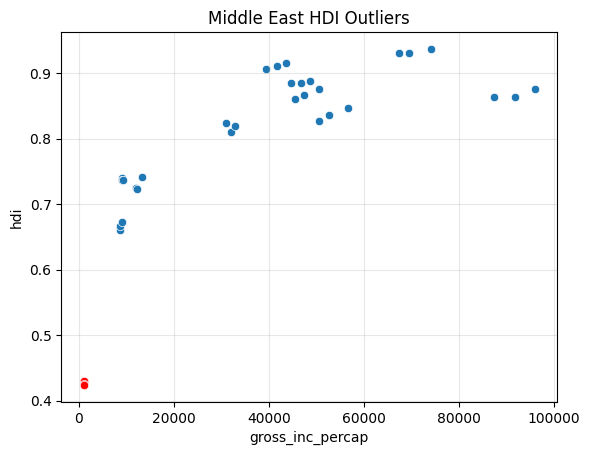

In [526]:
sns.scatterplot(data=me_2020_22, x='gross_inc_percap', y='hdi')
sns.scatterplot(data=me_outliers, x='gross_inc_percap', y='hdi', color='red')
plt.title("Middle East HDI Outliers")
plt.grid(True, alpha=0.3)
plt.show()

The outliers in the plots highlight significant inequalities within both regions. In South Asia, countries with unusually high or low HDI relative to their income indicate uneven access to education, healthcare, and living standards. In the Middle East, extreme outliers show that while some high-income countries achieve very high human development, others with low income and HDI are affected by conflict or instability. Overall, these outliers demonstrate that higher income does not always translate directly into higher human development.